<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; margin-bottom:1em; font-family:'Orbitron', sans-serif; 
            background: radial-gradient(ellipse at 10% 20%, #a8d8ff 0%, #6fb8ff 50%, #4a90e2 100%);
            box-shadow: 0px 8px 24px rgba(30,60,120,0.25); overflow:hidden;">
  <div style="font-size:150%; color:#154360; text-transform:uppercase;"><b>Paris coule t-il?</b></div>
  <div style="color:aliceblue">A visual data story by <a href="https://github.com/brooks-code" style="color:dodgerblue">brkln.</a></div>
</div>


 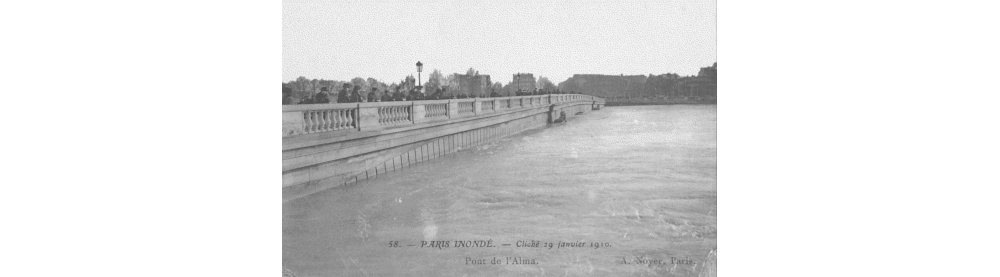<br> *On January 28th, the Seine reached its maximum level of 8.62 meters on the hydrometric scale at the Austerlitz Bridge in Paris.*

*Fluctuat nec mergitur*, "she is tossed by the waves but does not sink" evokes Parisian identity. This motto, that appears on the heraldic of the town conveys an ideal of perseverance, resilience and steadfastness in the face of adversity.

The Seine flood of 1910, often referred to as the hundred-year flood, was the most significant flooding of the Seine since 1658. The flood affected most of the river valley and, although it did not cause many deaths, it did cause significant damage to the Parisian economy. Paris is awaiting another flood of that scale and this notebook explores more than a hundred years worth of daily records.

---

> The main idea behind this work is to adapt ideas and leverage the code reusability from my last year's [submission](https://github.com/brooks-code/miniature-fortnight) to the [Hackaviz competition](https://toulouse-dataviz.fr/hackaviz/2026-contest/). The resulting data visualization helps visualize a [music inspired](https://en.wikipedia.org/wiki/Ridgeline_plot) and very creative design adapted from [C. Wilkes](https://en.wikipedia.org/wiki/Claus_O._Wilke) works.

This is an example of what you will get by the end of this notebook:

*Okay the vinyl part is just swag ;)*

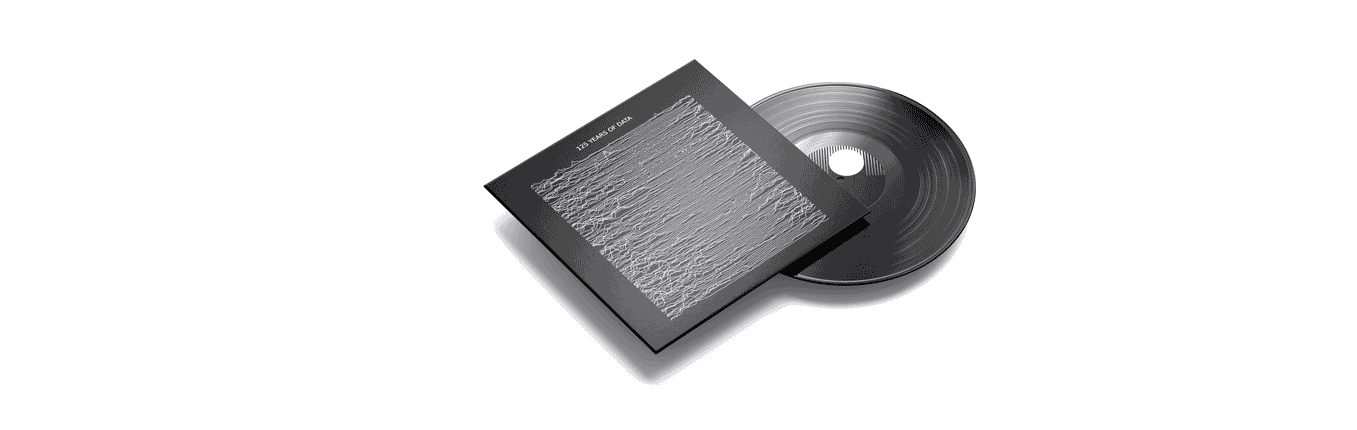

P.-S. I'm looking for musicians that could give me a hand in bootstraping something "actually" musical out of this project..

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Fluctuat nec mergitur dataset. A collection of the Seine water levels in Paris since 1900.">
  <div style="background:#f0f8ff;border:1px solid #b3d9e7;color:#0d3b5c;padding:10px 12px;border-radius:10px;
              box-shadow:0 8px 16px rgba(13,59,92,0.06);font-family:system-ui,-apple-system,'Segoe UI',Roboto,Arial;
              display:flex;gap:12px;align-items:flex-start;max-width:760px;box-sizing:border-box;">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;color:#1a7cb5;font-weight:700;font-size:20px;flex-shrink:0;">
    ⚙ 
    </div>
    <div style="display:block;">
      <div style="margin:0;font-weight:700;color:#10527a;font-size:15px;line-height:1.6;">Data engineer ?</div>
      <div style="margin:0;color:#18365b;font-size:13.5px;line-height:1.6;">The dataset building script is available!</div>
      <div style="margin:0;color:#2a5b7a;font-style:italic;font-size:12.5px;">
        <a href="https://github.com/brooks-code/paris-flood-dataset" target="_blank" rel="noopener noreferrer" style="color:#10527a;text-decoration:none;font-weight:600;">Discover it on GitHub</a>
      </div>
    </div>
  </div>
</div>


**Table of contents**<a id='toc0_'></a>    
- [**Paris coule t-il?**](#toc1_)    
  - [Where we will explore the data](#toc1_1_)    
  - [Exploratory data analysis](#toc1_2_)    
    - [Overview statistics](#toc1_2_1_)    
    - [Frequency Histograms](#toc1_2_2_)    
    - [Missing data analysis](#toc1_2_3_)    
      - [Absence of a value in the recordings](#toc1_2_3_1_)    
      - [Missing periods](#toc1_2_3_2_)    
    - [The flood alerts, a quick overview](#toc1_2_4_)    
    - [Detailed data distribution of the water-levels](#toc1_2_5_)    
    - [Outlier detection](#toc1_2_6_)    
  - [Having fun with Matplotlib: plotting and beyond](#toc1_3_)    
    - [You said joyplot?](#toc1_3_1_)    
      - [Classic: frequency distribution *(radio edit)*](#toc1_3_1_1_)    
      - [What's your ridge-limnigram flavor, monestre?](#toc1_3_1_2_)    
    - [More plots](#toc1_3_2_)    
      - [Plots by year](#toc1_3_2_1_)    
      - [Low-variability years](#toc1_3_2_2_)    
      - [Diverging years](#toc1_3_2_3_)    
        - [minmax years](#toc1_3_2_3_1_)    
        - [Most excessive year versus more consistent](#toc1_3_2_3_2_)    
    - [**Acknowledgements**](#toc1_3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

---

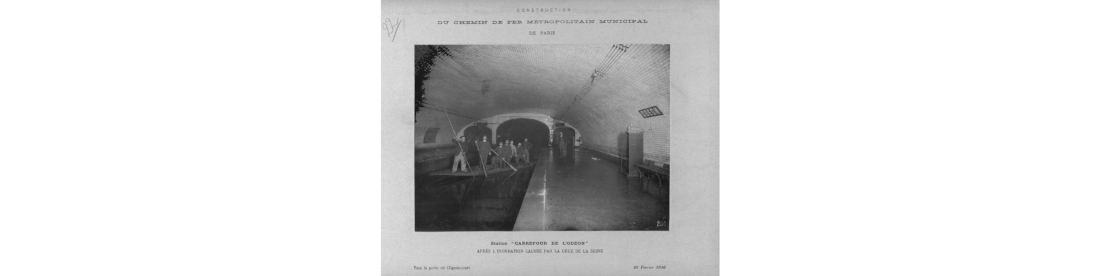<br> *At 5.10m the water starts pouring into stations through the vents.*(Archives de Paris)

---

## <a id='toc1_1_'></a>[Where we will explore the data](#toc0_)
♬ *Claudio Monteverdi - Vespro della Beata Vergine SV 206 n°7 "Duo Seraphim" (1610)*

Load libraries and helper functions

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

Setup

In [6]:
# install dependencies | Python 3.10+
# !pip install joypy==0.2.6 matplotlib==3.5.3 numpy==1.21.6 pandas==1.3.5 scipy==1.7.3 seaborn==0.13.2

# For Kaggle
!pip install joypy

* Imports from utility script

In [7]:
# Kaggle notebook needs to have this utility script added:
# https://www.kaggle.com/code/grimespoint/paris-flood-dataset-utility-script/notebook
from paris_flood_dataset_utility_script import plot_frequency_histogram, plot_missing_values, find_missing_periods, plot_distribution, detect_outliers, match_z_outliers_to_alert_ranges, flood_alert_stats

In [8]:
plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.use_mathtext"] = False
plt.rcParams["axes.formatter.limits"] = (-7, 7)
plt.rcParams["figure.dpi"] = 60 # 300 for print resolution

Datasets loading


In [9]:
historical_df = pd.read_csv("/kaggle/input/datasets/grimespoint/paris-flood-dataset/paris_flood_dataset.csv",
                            parse_dates=["record_date", "data_production_date"])

Main dataset
>125+ years of continuous data.

In [10]:
historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53331 entries, 0 to 53330
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   location_code           53331 non-null  object             
 1   station_code            53331 non-null  object             
 2   record_date             53331 non-null  datetime64[ns]     
 3   water_level_mm          53331 non-null  float64            
 4   data_production_date    53331 non-null  datetime64[ns, UTC]
 5   validation_status_code  53331 non-null  int64              
 6   validation_status       53331 non-null  object             
 7   production_method_code  53331 non-null  int64              
 8   production_method       53331 non-null  object             
 9   quality_code            53331 non-null  int64              
 10  quality_assessment      53331 non-null  object             
 11  longitude               53331 non-null  f

## <a id='toc1_2_'></a>[Exploratory data analysis](#toc0_)

### <a id='toc1_2_1_'></a>[Overview statistics](#toc0_)

In [11]:
display(historical_df["water_level_mm"].describe())

count   53331.00
mean     1462.78
std       775.94
min     -1253.00
25%      1014.00
50%      1158.00
75%      1593.00
max      8620.00
Name: water_level_mm, dtype: float64

This is a large sample (53,331 entries).
The mean (1463) well above the median (1158) indicates a right-skewed distribution with a substantial spread (std 776) and a long upper tail (max 8620).

IQR = Q3 - Q1;
IQR = 1593.00 - 1014.00 = 579.00 (mm). IQR (579) is moderate: most values fall between 1014 and 1593.

In [12]:
print("Count of distinct values for dataset:")
historical_df.nunique()

Count of distinct values for dataset:


location_code                 1
station_code                  5
record_date               46060
water_level_mm             3866
data_production_date        225
validation_status_code        3
validation_status             3
production_method_code        3
production_method             3
quality_code                  3
quality_assessment            3
longitude                     2
latitude                      2
hubeau_elab_code              1
flood_alert                   2
dtype: int64

Only three features contain high cardinality values.

| Column                     | Distinct count | Comment |
|---------------------------:|---------------:|---------|
| location_code              | 1              | Single location/source |
| station_code               | 5              | Few stations - check the whereabouts of this multiplicity |
| record_date                | 46,060         | High temporal resolution (many unique timestamps) |
| water_level_mm             | 3,866          | Many unique values |
| data_production_date       | 225            | Data updated in batches or multiple production runs |
| validation_status_code     | 3              | Small set of validation flags |
| validation_status          | 3              | Same categories as validation_status_code |
| production_method_code     | 3              | Few production methods recorded |
| production_method          | 3              | Same categories as production_method_code |
| quality_code               | 3              | Small set of quality flags |
| quality_assessment         | 3              | Same categories as quality_code |
| longitude                  | 2              | Two unique coordinates - verify correctness |
| latitude                   | 2              | Two unique coordinates - verify correctness |
| hubeau_elab_code          | 1              | Single code |
| flood_alert                | 2              | Binary alert indicator (True/False) |

In [13]:
print("Count of duplicate values, row wise:")
# only additional duplicates are counted (first occurrence is excluded).
print(historical_df.duplicated().sum())
# all occurrences of a duplicate row are counted
print(historical_df.duplicated(keep=False).sum())
# consider duplication based on the subset
# counts every row that shares the same "record_date" value with another row.
print(historical_df.duplicated(subset=["record_date"], keep=False).sum())

Count of duplicate values, row wise:
0
0
14542


No duplicate rows. Just note this: we can have different recordings registered on the same day (14542) -but by different stations. Let's dig that a bit.

In [14]:
station_recording_range = historical_df.groupby("station_code")["record_date"].agg(
    ["min", "max"]).rename(columns={"min": "first_recording", "max": "latest_recording"}).reset_index()
station_recording_range

,station_code,first_recording,latest_recording
0,F700000102,1990-01-02,2026-02-28
1,F700000103,2006-01-27,2026-02-28
2,F700000109,1900-01-02,1965-12-30
3,F700000110,1966-01-02,1973-12-30
4,F700000111,1974-01-02,1989-12-30


Okay, the recordings of these two stations (`F700000102` and `F700000103`) overlap. This is a normal situation explained on the [hydroportail portal](https://www.hydro.eaufrance.fr/stationhydro/F700000102/fiche) where `F700000102` acts as a backup for `F700000103` since 2006.

### <a id='toc1_2_2_'></a>[Frequency Histograms](#toc0_)
First, let's visually check the frequencies distribution of the dataset, this will allow a quick identification of patterns and potential outliers within the data.

Univariate histograms for :


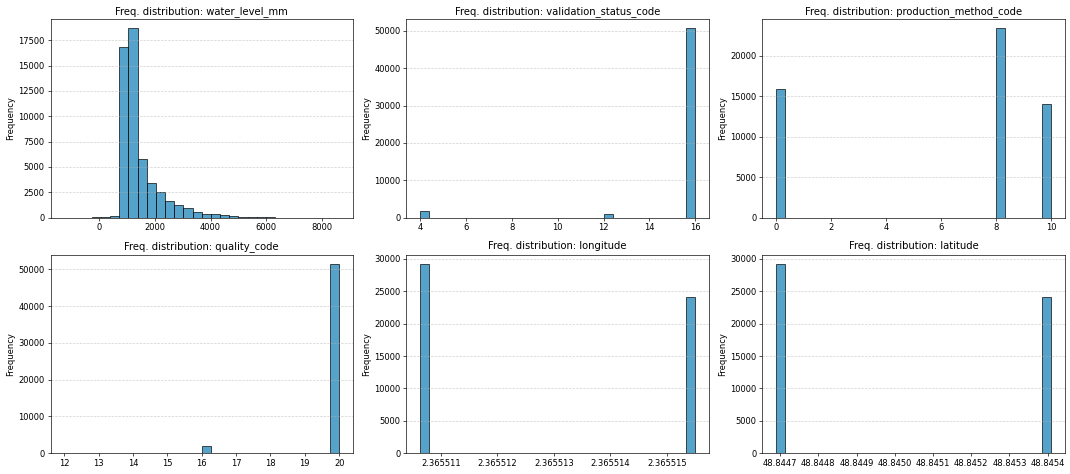

In [15]:
print("Univariate histograms for :")
plot_frequency_histogram(historical_df)

`water_level_mm` is the main feature: most of the data points are clustered around a smaller range, with fewer occurrences as the values increase.
Regarding the others features. They are containing [classes](https://github.com/brooks-code/paris-flood-dataset/blob/main/doc/codes%20observations%20hydro.pdf): usually, one category significantly outweighs the others.

### <a id='toc1_2_3_'></a>[Missing data analysis](#toc0_)

#### <a id='toc1_2_3_1_'></a>[Absence of a value in the recordings](#toc0_)
Do we have recordings that have `null` values?

In [16]:
plot_missing_values(historical_df) #TODO heatmap: on large datasets missing values do not appear.

Missing values per column:
location_code             0
station_code              0
record_date               0
water_level_mm            0
data_production_date      0
validation_status_code    0
validation_status         0
production_method_code    0
production_method         0
quality_code              0
quality_assessment        0
longitude                 0
latitude                  0
hubeau_elab_code          0
flood_alert               0
dtype: int64
No missing data found. Plot not necessary.


#### <a id='toc1_2_3_2_'></a>[Missing periods](#toc0_)
Gaps in time series data specifically refer to periods where data points are missing due to the absence of observations for certain time intervals. It's important to know if we have (significant) gaps between some records. Since the first recording, dating back to 1900 until the last record from Feb. 2026, we should have at least one observation per day. 

In [17]:
display(find_missing_periods(historical_df))

{'missing_years': {'F7000001': []},
 'missing_months': {'F7000001': []},
 'missing_days': {'F7000001': ['1965-12-31',
   '1966-01-01',
   '1973-12-31',
   '1974-01-01',
   '1989-12-31',
   '1990-01-01',
   '1992-06-29',
   '1992-06-30',
   '1992-07-01',
   '1992-07-02',
   '1992-07-03',
   '1992-07-04',
   '1994-09-06',
   '1994-09-23',
   '1994-09-30',
   '1995-10-20',
   '1998-12-31',
   '1999-05-20',
   '2000-04-03']}}

**19 missing days**, most occur during the new year period (`xxxx-12-31` & `xxxx-01-01`).

No whole years or months worth of data are missing (*pfioo!*).

### <a id='toc1_2_4_'></a>[The flood alerts, a quick overview](#toc0_)

Defining what's a flood in terms of data science is quite empiric and each choice has its drawbacks. The choice in this dataset has been made to set it at a **threshold** (6000 mm) which is close to the one used by some of the Parisian authorities to undertake critical actions (closing roads...). Let's gather some basic statistics.

In [18]:
display(flood_alert_stats(historical_df))

Overall longest alert: 14 days
- Group F7000001: 1910-01-22 to 1910-02-04


{'F7000001': {'count': 63,
  'mean': 6691.3650793650795,
  'median': 6561.0,
  'min': 6001.0,
  'max': 8620.0,
  'std': 698.4797846567932,
  'date_ranges': [('1910-01-22', '1910-02-04'),
   ('1919-01-09', '1919-01-10'),
   ('1920-01-02', '1920-01-07'),
   ('1924-01-01', '1924-01-09'),
   ('1926-01-08', '1926-01-09'),
   ('1930-12-01', '1930-12-02'),
   ('1944-12-03', '1944-12-04'),
   ('1945-02-12', '1945-02-18'),
   ('1955-01-20', '1955-01-27'),
   ('1959-01-17', '1959-01-20'),
   ('1982-01-13', '1982-01-15'),
   ('2016-06-03', '2016-06-04')],
  'longest_alert_days': 14}}

The flood alert subset (`flood_alert` is `True`) consists of 63 observations with a max consecutive range of alerts lasting for 14 days.

Median: at 6561.00, this value is slightly lower than the mean, suggesting that there may be some higher values pulling the mean uprange. The std deviation of 698.48 indicates a moderate variability around the mean. This suggests that while most values are close to the mean, there are notable fluctuations as well.

In [19]:
# datetime and filter alert rows
historical_df["record_date"] = pd.to_datetime(
    historical_df["record_date"], errors="coerce")
alert_df = historical_df[historical_df["flood_alert"].astype(
    bool)].dropna(subset=["record_date"])

# extract month number and month name
alert_df["month_num"] = alert_df["record_date"].dt.month
alert_df["month_name"] = alert_df["record_date"].dt.month_name()

# or count by month name, ordered by month number
month_name_counts = alert_df.groupby("month_num")["month_name"].first(
).to_frame().join(alert_df["month_num"].value_counts(), how="right").sort_index()
month_name_counts.columns = ["month_name", "count"]
top_n = month_name_counts.nlargest(3, "count")
display(top_n)

,month_name,count
month_num,,
1,January,44
2,February,11
6,June,4


Most flood alert records were recorded between **January and February**. This confirms the fact that in the Paris region, the Seine flooding season is often winter time, typical of plain floods due to an accumulation of water on wet lowlands soils. This type of flooding leads to slow paced water-level rising (and decrease) that can linger for days. This is quite different from what can be seen in town like [Toulouse](https://github.com/brooks-code/miniature-fortnight/blob/main/processing/dataswag_dataviz.ipynb) where the Garonne water-level rises much faster.

### <a id='toc1_2_5_'></a>[Detailed data distribution of the water-levels](#toc0_)

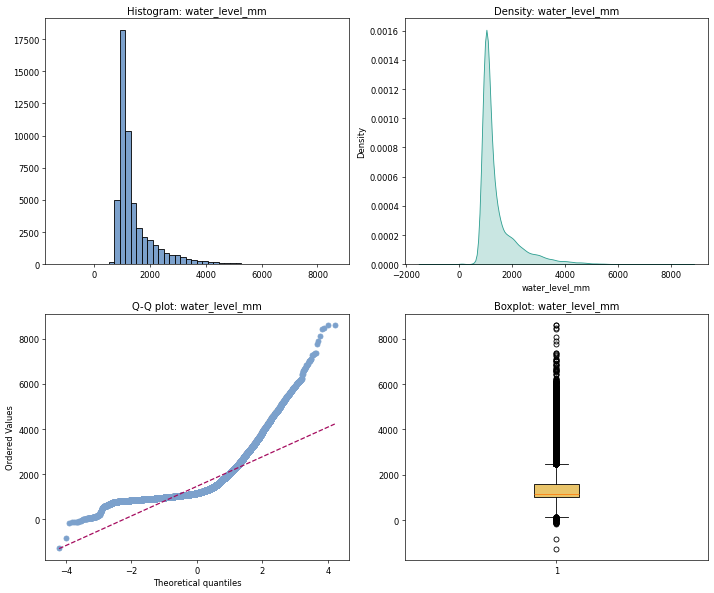

water_level_mm — mean: 1462.775777690274, med.: 1158.0, mode: 900.0, std: 775.9407580594055, skew.: 2.499231182548782, kurt.: 7.939095022856426


In [20]:
plot_distribution(historical_df, cols="water_level_mm", grid=True)

These plots represent different statistical visualizations related to the `"water_level_mm"` column (expressed in *mm*).

- Histogram
  - *Shape:* the histogram shows a right-skewed distribution. Most water level values are concentrated at lower levels, with fewer instances of extremely high levels.
  - *Interpretation:* the majority of water levels fall below 6000 mm, indicating that high levels are outliers rather than common occurrences. The right tail suggests that during specific events, water levels can spike significantly.

- Density Plot
  - *Shape:* similar to the histogram, the density plot confirms the right-skewed distribution.
  - *Interpretation:* extreme water levels are rare.

- Q-Q Plot
  - *Assessment of normality:* the Q-Q plot compares the quantiles of the water level data against a theoretical normal distribution.
  - *Interpretation:* points deviating from the diagonal line suggest that the data does not follow a normal distribution. This supports the observation of right skewness in the histogram and density plots.

- Box Plot
  - *Summary:* the box plot summarizes the five-number statistic (minimum, first quartile, median, third quartile, and maximum).
  - *Interpretation:* there are visible outliers, indicated by individual points beyond the whiskers. The interquartile range (IQR) is moderate, but the presence of outliers indicates significant variability in extreme water levels.

**Conclusion:** right-skewness is assessed and if we were to use some traditional statistical methods assuming normality. Transformations or non-parametric methods should be then needed for a further analysis.

Note: We don't have hardly-logical-physics-defying data points in this dataset but let's investigate a bit more the extreme values.

### <a id='toc1_2_6_'></a>[Outlier detection](#toc0_)
* We will use the Z-score. It is a statistical measure that indicates how many standard deviations a data point is from the mean.
* By manually tweaking the z-score threshold value we will filter out suspicious data points to our convenience.<br>
*(A nice + to have would be to automate it, since we can fetch contextual historical data about the floods)*

In [21]:
z_score_outliers = detect_outliers(historical_df, group_by='location_month')
z_score_outliers

1 days containing 1 outliers


,location_code,station_code,record_date,water_level_mm,data_production_date,validation_status_code,validation_status,production_method_code,production_method,quality_code,quality_assessment,longitude,latitude,hubeau_elab_code,flood_alert,year_month,n,mean,std,z_score
263,F7000001,F700000109,1900-09-22,853.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,False,1900-09,30,898.43,8.58,-5.29


With the current setting, 1 record is flagged.<br>Buuut... We do not want a legitimate data point to be incorrectly classified *(false positive)*. So let's make sure we don't flag data that actually belongs to a natural pattern. High water-levels represent a significant event that are perfectly normal when there is a flood.

In [22]:
stats = flood_alert_stats(historical_df)
matches = match_z_outliers_to_alert_ranges(z_score_outliers, stats)
if matches.empty:
    print("No false positive detected.")
else:
    print("Rows from z_score_outliers that fall within one of the flood date_range intervals:")
    print(matches)

Overall longest alert: 14 days
- Group F7000001: 1910-01-22 to 1910-02-04
No false positive detected.


If data point status cleared, we can filter out these records safely.

In [23]:
# df_filtered_outliers = historical_df[~historical_df.index.isin( z_score_outliers.index)]

Check the maximum values of the dataset: they should match the historical records from the 1910 peak..

In [24]:
# top8_filtered = df_filtered_outliers.nlargest(8, "water_level_mm")

top7 = historical_df.nlargest(7, "water_level_mm")
top7

,location_code,station_code,record_date,water_level_mm,data_production_date,validation_status_code,validation_status,production_method_code,production_method,quality_code,quality_assessment,longitude,latitude,hubeau_elab_code,flood_alert
3678,F7000001,F700000109,1910-01-28,8620.00,2025-06-17 09:27:10+00:00,16,validated,0,measured,20,good,2.37,48.85,HIXnJ,True
3679,F7000001,F700000109,1910-01-29,8610.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,True
3677,F7000001,F700000109,1910-01-27,8483.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,True
3680,F7000001,F700000109,1910-01-30,8420.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,True
3681,F7000001,F700000109,1910-01-31,8098.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,True
3676,F7000001,F700000109,1910-01-26,7911.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,True
3682,F7000001,F700000109,1910-02-01,7750.00,2025-06-17 09:27:10+00:00,16,validated,0,measured,20,good,2.37,48.85,HIXnJ,True


---

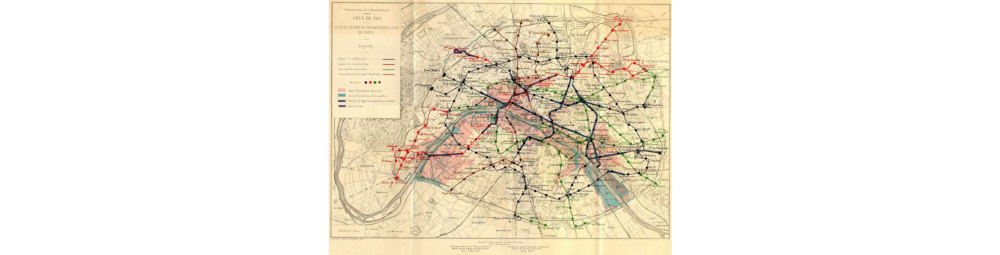 <br>*An older Paris metro map with the flooded area in pink.* (Archives de Paris)

---

## <a id='toc1_3_'></a>[Having fun with Matplotlib: plotting and beyond](#toc0_)
♫ *Molly Lewis - Nature Boy (2022)*

In [25]:
from paris_flood_dataset_utility_script import prepare_data, plot_unknown_pleasures, plot_byflavor, plot_years, plot_stable_years, plot_diverging_years, STYLES

### <a id='toc1_3_1_'></a>[You said joyplot?](#toc0_)

A Joyplot, also known as a ridgeline plot is a type of data visualization that displays the distribution of a variable over time or across different categories. Multiple density plots or histograms are stacked vertically, with each row representing a different time period or category. The overlaid plots are creating a sense of depth and allow the viewer to see how the distribution changes.<br> The name [Joyplot](https://en.wikipedia.org/wiki/Ridgeline_plot) is derived from the use of a ridgeline plot of the intensity of pulses from a pulsar on the front of Joy Division's album [Unknown Pleasures](https://en.wikipedia.org/wiki/Unknown_Pleasures).

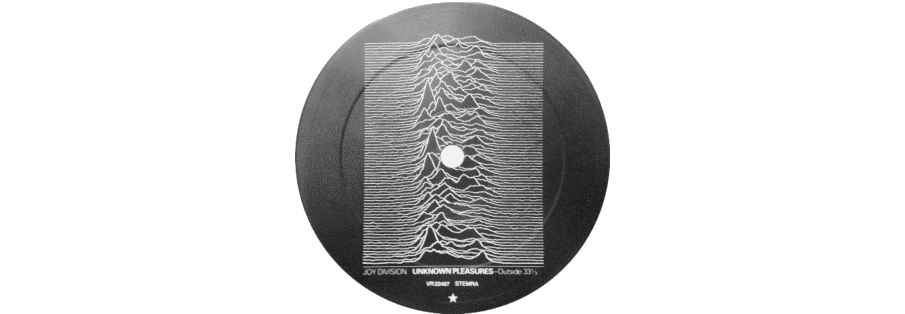

#### <a id='toc1_3_1_1_'></a>[Classic: frequency distribution *(radio edit)*](#toc0_)

Joyplot style ofc! As a *warmup* le't try to replicate the design with our data. We basically make a tailored use of the [joypy package](https://leotac.github.io/posts/2017/08/01/joypy/).

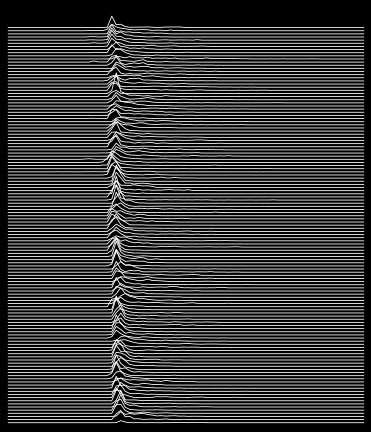

In [26]:
plot_unknown_pleasures(historical_df)

Cute, no? This is a ridgeline plot of the daily‐maximum heights **counts** with uniform x-limits across all years. The ridges are stacked from 1900 to the bottom up to 2025 to the top.  The range of heights is divided into 80 equally‐sized intervals (bins). Stacked together the ridges show how the empirical distribution of daily maxima changes from year to year..

>**PS:** For readability, if you want to display the x-axis labels..<br> 
>In the helper function (located in `paris_dataset_flood_helper.py`):<br> 
>`def plot_unknown_pleasures(df: pd.DataFrame) -> None:`<br> 
>`"""Plot classic joyplot of daily-max heights by year."""`<br>
> → go to the `joyplot()` subfunction parameters and set `xlabels=False` to `True`.

#### <a id='toc1_3_1_2_'></a>[What's your ridge-limnigram flavor, monestre?](#toc0_)
Where we focus on daily maxima

Prepare the data once (and for all).

In [27]:
# Filter out the current (incomplete) year
df_filtered_year = historical_df[historical_df['record_date'].dt.year != 2026]

In [28]:
data_by_year, labels, daily = prepare_data(
    df_filtered_year, "record_date", "water_level_mm")

>Now the *plat de résistance*. I can't recall exactly how that idea occured but I remember I thought about tree rings at some point of the competition. Do you know what [dendrochronology](https://upload.wikimedia.org/wikipedia/commons/b/b2/Tree_cookie_in_Royal_Ontario_Museum_2023a.jpg) is? It's like time traveling where thanks to tree rings you can catch many curiosities like ancient events but also climatological episodes *carved* inside the wood.<br>

So here we go, we will get a ridgeline plot of daily maximum water‐heights, one line per year (newest at the top), declined in flavors that are highlighting some aspects of the dataset. For example *'calm'* is emphasizing the years with less fluctuations in distinct colors (darker is more stable in this case).
<br>Many flavors are on the menu. *Pick yours*.

<br> **N.B**: You might see some gaps on some lines: this relates to missing time periods (as seen [above!](#missing-periods)).

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Fluctuat nec mergitur dataset. A collection of the Seine water levels in Paris since 1900.">
  <div style="background:#f0f8ff;border:1px solid #b3d9e7;color:#0d3b5c;padding:10px 12px;border-radius:10px;
              box-shadow:0 8px 16px rgba(13,59,92,0.06);font-family:system-ui,-apple-system,'Segoe UI',Roboto,Arial;
              display:flex;gap:12px;align-items:flex-start;max-width:760px;box-sizing:border-box;">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;color:#1a7cb5;font-weight:700;font-size:20px;flex-shrink:0;">
    ! 
    </div>
    <div style="display:block;">
      <div style="margin:0;font-weight:700;color:#10527a;font-size:15px;line-height:1.6;">TIP</div>
      <div style="margin:0;color:#18365b;font-size:13.5px;line-height:1.6;">In the top of the notebook, set plt.rcParams["figure.dpi"] = 300 for print resolution</div>
      <div style="margin:0;color:#2a5b7a;font-style:italic;font-size:12.5px;">
        <a href="https://www.kaggle.com/discussions/product-feedback/491366" target="_blank" rel="noopener noreferrer" style="color:#10527a;text-decoration:none;font-weight:600;">Small resolution is due to Kaggle kernel limits.</a>
      </div>
    </div>
  </div>
</div>


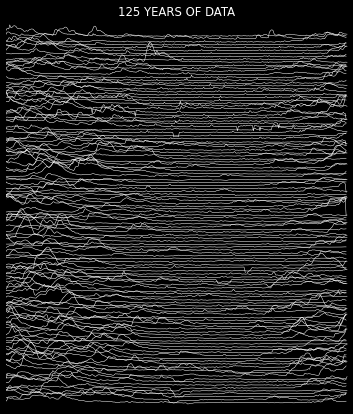

In [29]:
# a) Choose your style.. "classic", "calm", "excess" or "lutetia"
plot_byflavor(data_by_year.copy(), labels, daily, style_key='classic')

Try this one :)

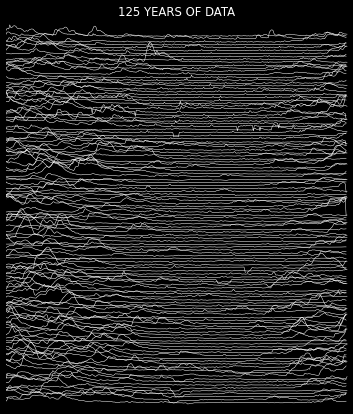

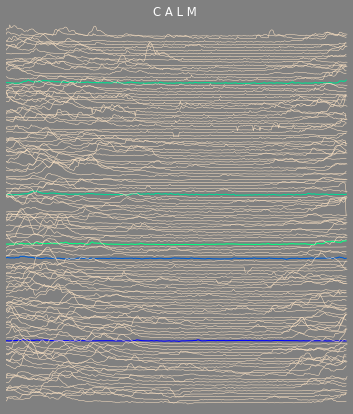

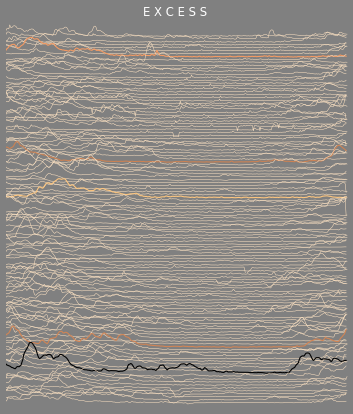

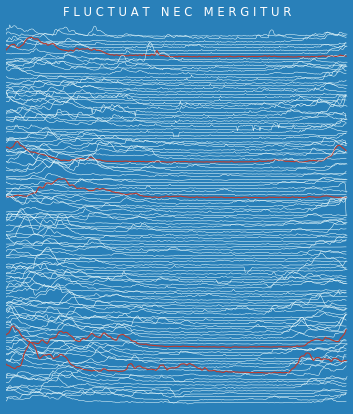

In [30]:
# b) ..or display them all
for key in STYLES:
    plot_byflavor(data_by_year.copy(), labels, daily, style_key=key)

### <a id='toc1_3_2_'></a>[More plots](#toc0_)

**Note:** Regarding the following plots, data point between missing are interpolated in order to appear connected. In the `plot_years` and `plot_diverging_years` functions, this can be adjusted.

In [31]:
# From now, dark mode.
plt.style.use("dark_background")

#### <a id='toc1_3_2_1_'></a>[Plots by year](#toc0_)

This is tinkered as a quick toolbox for when you're curious about specific years.

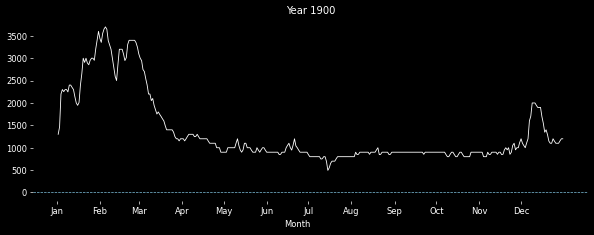

In [32]:
# plot a single year, a range(xxxx, xxxx), or an arbitrary list [xxxx, xxxx, xxxx]
plot_years(data_by_year, labels, 1900, interpolate_gaps=False)

#### <a id='toc1_3_2_2_'></a>[Low-variability years](#toc0_)

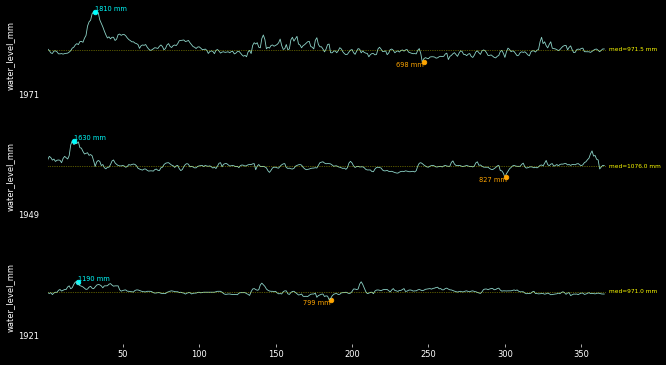

In [33]:
plot_stable_years(data_by_year, labels, interpolate_gaps=True, n_years=3)

#### <a id='toc1_3_2_3_'></a>[Diverging years](#toc0_)

##### <a id='toc1_3_2_3_1_'></a>[minmax years](#toc0_)

In [34]:
df_filtered_year.nsmallest(4, "water_level_mm")

,location_code,station_code,record_date,water_level_mm,data_production_date,validation_status_code,validation_status,production_method_code,production_method,quality_code,quality_assessment,longitude,latitude,hubeau_elab_code,flood_alert
17057,F7000001,F700000109,1946-09-15,-1253.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,False
17058,F7000001,F700000109,1946-09-16,-820.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,False
17059,F7000001,F700000109,1946-09-17,-172.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,False
15575,F7000001,F700000109,1942-08-25,-139.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,False


In [35]:
df_filtered_year.nlargest(4, "water_level_mm")

,location_code,station_code,record_date,water_level_mm,data_production_date,validation_status_code,validation_status,production_method_code,production_method,quality_code,quality_assessment,longitude,latitude,hubeau_elab_code,flood_alert
3678,F7000001,F700000109,1910-01-28,8620.00,2025-06-17 09:27:10+00:00,16,validated,0,measured,20,good,2.37,48.85,HIXnJ,True
3679,F7000001,F700000109,1910-01-29,8610.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,True
3677,F7000001,F700000109,1910-01-27,8483.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,True
3680,F7000001,F700000109,1910-01-30,8420.00,2025-06-17 09:27:10+00:00,16,validated,8,calculated,20,good,2.37,48.85,HIXnJ,True


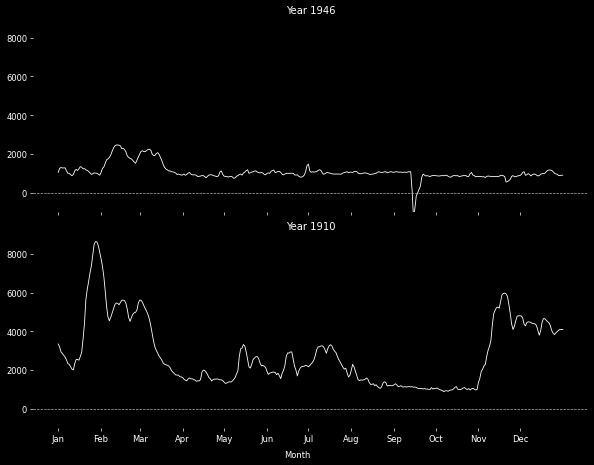

In [36]:
plot_diverging_years(
    data_by_year, labels,
    years=[1946, 1910], interpolate_gaps=True)

##### <a id='toc1_3_2_3_2_'></a>[Most excessive year versus more consistent](#toc0_)

In [37]:
yearly_df = df_filtered_year.copy()
yearly_df["Year"] = yearly_df["record_date"].dt.year
yearly_df["Day"] = yearly_df["record_date"].dt.dayofyear

year_std = yearly_df.groupby("Year")["water_level_mm"].std()

print(f"Years with low variability: {year_std.nsmallest(5).index.tolist()}")
print(f"Years with high variability: {year_std.nlargest(5).index.tolist()}")

Years with low variability: [1921, 1949, 1971, 2009, 1954]
Years with high variability: [1910, 1919, 2018, 1982, 1970]


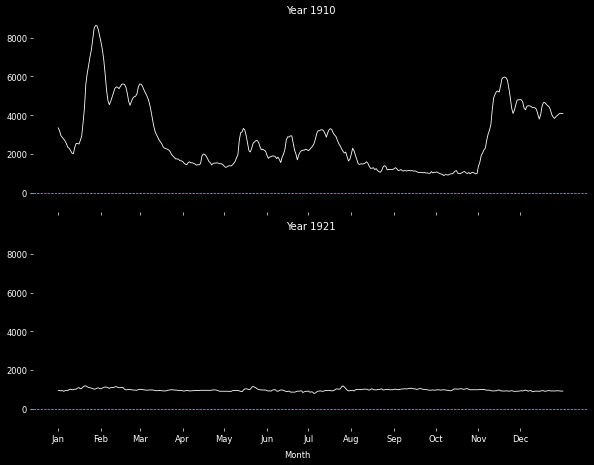

In [38]:
plot_diverging_years(
    data_by_year, labels,
    years=[1910, 1921])

That's all folks.

In [39]:
display(HTML('''
<a href="https://commons.wikimedia.org/wiki/File:Armoiries_de_la_ville_de_Paris_(1949).svg#/media/Fichier:Armoiries_de_la_ville_de_Paris_(1949).svg">
  <img src="https://upload.wikimedia.org/wikipedia/commons/5/51/Armoiries_de_la_ville_de_Paris_%281949%29.svg" 
       alt="Image illustrative de l'article Blason de Paris" 
       width="300" 
       height="300">
</a>
<br>
Par <a href="//commons.wikimedia.org/w/index.php?title=User:RaphaëlMignon&action=edit&redlink=1">RaphaëlMignon</a> 
<span class="int-own-work" lang="fr"></span>, 
<a rel="nofollow" class="external text" href="https://www.paris.fr/pages/fluctuat-nec-mergitur-l-histoire-de-la-devise-de-paris-15814">paris.fr</a>, 
<a href="https://creativecommons.org/licenses/by/4.0">CC BY 4.0</a>
'''))

### <a id='toc1_3_3_'></a>[**Acknowledgements**](#toc0_)
Specialists behind the [hydroportail](https://hydro.eaufrance.fr/) and [Hub'Eau](https://hubeau.eaufrance.fr/) API. 
The [joypy](https://pypi.org/project/joypy/) library authors.<br>
All the open source libraries used.. Thank you all.

*(2026) Notebook provided by [♖](github.com/brooks-code) under an [Apache 2.0](https://www.apache.org/licenses/LICENSE-2.0.txt) license.*